1. Imports

In [13]:

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")


2. Load and preview

In [ ]:


df = pd.read_csv("../data/sierraleone-bumbuna.csv")
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  object 
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600 non-null  float64
 17  TModB          525600 non-nul

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-30 00:01,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.1,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
1,2021-10-30 00:02,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
2,2021-10-30 00:03,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
3,2021-10-30 00:04,-0.7,0.0,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.1,22.3,22.6,NaN
4,2021-10-30 00:05,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN


3. Timestamp -> datetime

In [ ]:


df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y-%m-%d %H:%M', errors='coerce')

df = df.sort_values('Timestamp').reset_index(drop=True)


 4. Replace impossible negatives for irradiance/module readings



In [ ]:

for c in ['GHI','DNI','DHI','ModA','ModB']:
    df[c] = df[c].apply(lambda x: np.nan if (isinstance(x,(int,float)) and x < 0) else x)


 5. Numeric columns list


In [ ]:

numeric_cols = ['GHI','DNI','DHI','ModA','ModB','Tamb','RH','WS','WSgust','WSstdev','BP','Precipitation','TModA','TModB']


 6. Summary


In [ ]:

display(df[numeric_cols].describe())
display(df.isna().sum())


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,BP,Precipitation,TModA,TModB
count,264465.000000,259248.000000,262472.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000
mean,406.239777,236.240484,232.837959,206.643095,198.114691,26.319394,79.448857,1.146113,1.691606,0.363823,999.876469,0.004806,32.504263,32.593091
std,305.063927,261.871060,149.104425,300.896893,288.889073,4.398605,20.520775,1.239248,1.617053,0.295000,2.104419,0.047556,12.434899,12.009161
min,0.000000,0.000000,0.000000,0.000000,0.000000,12.300000,9.900000,0.000000,0.000000,0.000000,993.000000,0.000000,10.700000,11.100000
25%,132.800000,1.200000,113.600000,0.000000,0.000000,23.100000,68.700000,0.000000,0.000000,0.000000,999.000000,0.000000,23.500000,23.800000
50%,359.500000,115.300000,225.000000,3.600000,3.400000,25.300000,85.400000,0.800000,1.600000,0.400000,1000.000000,0.000000,26.600000,26.900000
75%,654.400000,461.500000,337.400000,359.500000,345.400000,29.400000,96.700000,2.000000,2.600000,0.600000,1001.000000,0.000000,40.900000,41.300000
max,1499.000000,946.000000,892.000000,1507.000000,1473.000000,39.900000,100.000000,19.200000,23.900000,4.100000,1006.000000,2.400000,72.800000,70.400000


Timestamp             0
GHI              261135
DNI              266352
DHI              263128
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64

 7. Median imputation


In [ ]:

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())


 8. Z-score outlier detection


In [ ]:

z = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))
outlier_mask = (z > 3).any(axis=1)
print("Outliers rows:", outlier_mask.sum())

df_clean = df.loc[~outlier_mask].copy()


Outliers rows: 31909


 9. Plots (examples)


c:\Users\Temesgen Gonfa\Projects\Assessment\solar-challenge-week0\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


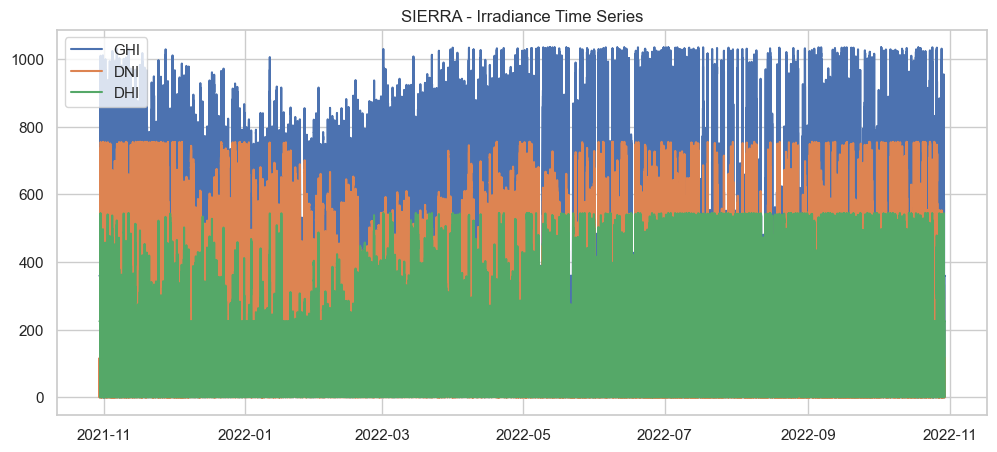

In [ ]:

plt.figure(figsize=(12,5))
plt.plot(df_clean['Timestamp'], df_clean['GHI'], label='GHI')
plt.plot(df_clean['Timestamp'], df_clean['DNI'], label='DNI')
plt.plot(df_clean['Timestamp'], df_clean['DHI'], label='DHI')
plt.legend(); plt.title("SIERRA - Irradiance Time Series"); plt.show()


 10. Cleaning impact


In [ ]:

display(df_clean.groupby('Cleaning')[['ModA','ModB']].mean())


,ModA,ModB
Cleaning,,
0,178.563029,170.976368
1,272.539053,276.273767


 11. Save cleaned file (do not commit data CSV to git — ../data/ is ignored)


In [ ]:

df_clean.to_csv("../data/sierraleone_clean.csv", index=False)